# Task 2 — Pipeline Proposal & Baseline Experimentation

Predicting USD/IDR (JISDOR) directional movement from historical exchange-rate
behaviour and geopolitical/economic news sentiment.

**News source:** CNBC (cnbc.com), collected directly via its public sitemaps
(`src/cnbc_sitemap_scraper.py`), filtered to articles within the study window
(2021-09-01 to 2026-09-01) whose URL slug matches one of 11 geopolitical/
economic topics relevant to the USD/IDR hypothesis.

**Constraint:** per the task brief, only lexicon-based sentiment (VADER,
Loughran-McDonald) and classical vectorization (TF-IDF) are used — no
transformer or pre-trained embedding models.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")
sys.path.insert(0, "src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from task2_pipeline import *

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 5)
print("Environment ready.")

Environment ready.


## 1. Data Loading

In [2]:
df_rates = pd.read_csv(FX_PATH, parse_dates=["Date"])
df_news_raw = pd.read_csv(NEWS_RAW_PATH)

print(f"USD/IDR: {len(df_rates)} trading days ({df_rates['Date'].min().date()} to {df_rates['Date'].max().date()})")
print(f"CNBC news (raw, scrape in progress): {len(df_news_raw)} articles")

USD/IDR: 1202 trading days (2021-09-01 to 2026-09-01)
CNBC news (raw, scrape in progress): 20842 articles


## 2. News Cleaning

Deduplicate near-identical titles (wire-style CNBC headline variants), drop
short/boilerplate extractions, and align each article's publish date to the
next available JISDOR trading day (business-day roll-forward, as validated in
Task 1).

In [3]:
df_news_clean = clean_news(df_news_raw)
df_news_clean = align_to_trading_days(df_news_clean)

print(f"After cleaning + dedup: {len(df_news_clean)} articles")
print(f"Date range: {df_news_clean['Date'].min().date()} to {df_news_clean['Date'].max().date()}")
print(f"Unique trading days with news: {df_news_clean['Aligned_Date'].nunique()}")

After cleaning + dedup: 19512 articles
Date range: 2021-09-01 to 2026-09-01
Unique trading days with news: 1201


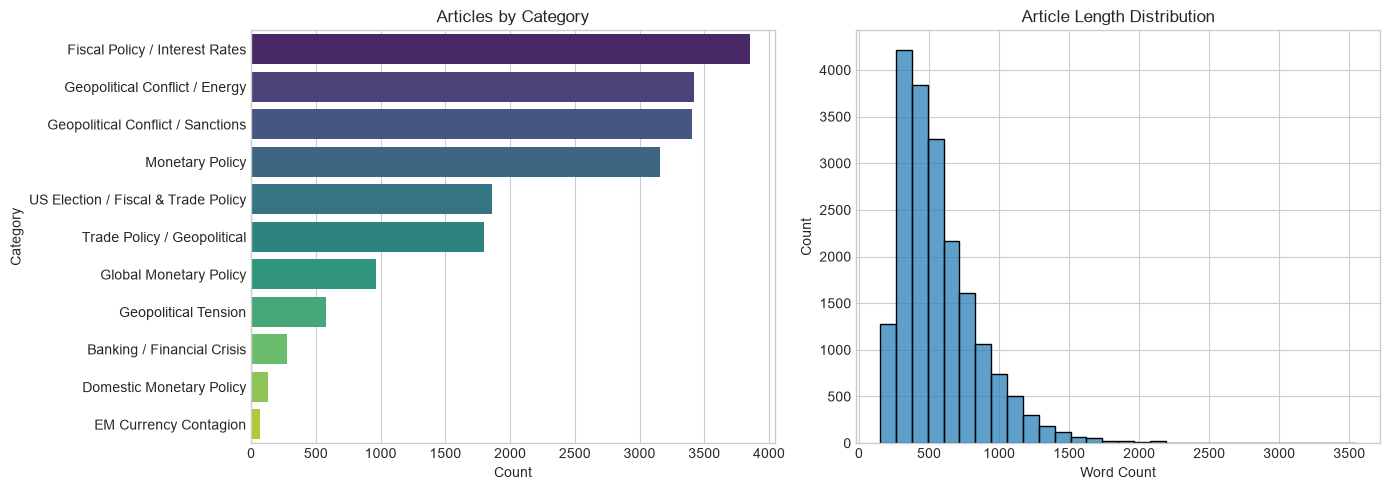

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_news_clean["Category"].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax1, palette="viridis")
ax1.set_title("Articles by Category")
ax1.set_xlabel("Count")

df_news_clean["word_count"] = df_news_clean["Text_clean"].str.split().str.len()
sns.histplot(df_news_clean["word_count"], bins=30, ax=ax2, color="#2980b9")
ax2.set_title("Article Length Distribution")
ax2.set_xlabel("Word Count")

plt.tight_layout()
plt.show()

## 3. Exchange Rate Feature Engineering

Trading days with complete technical features: 1181


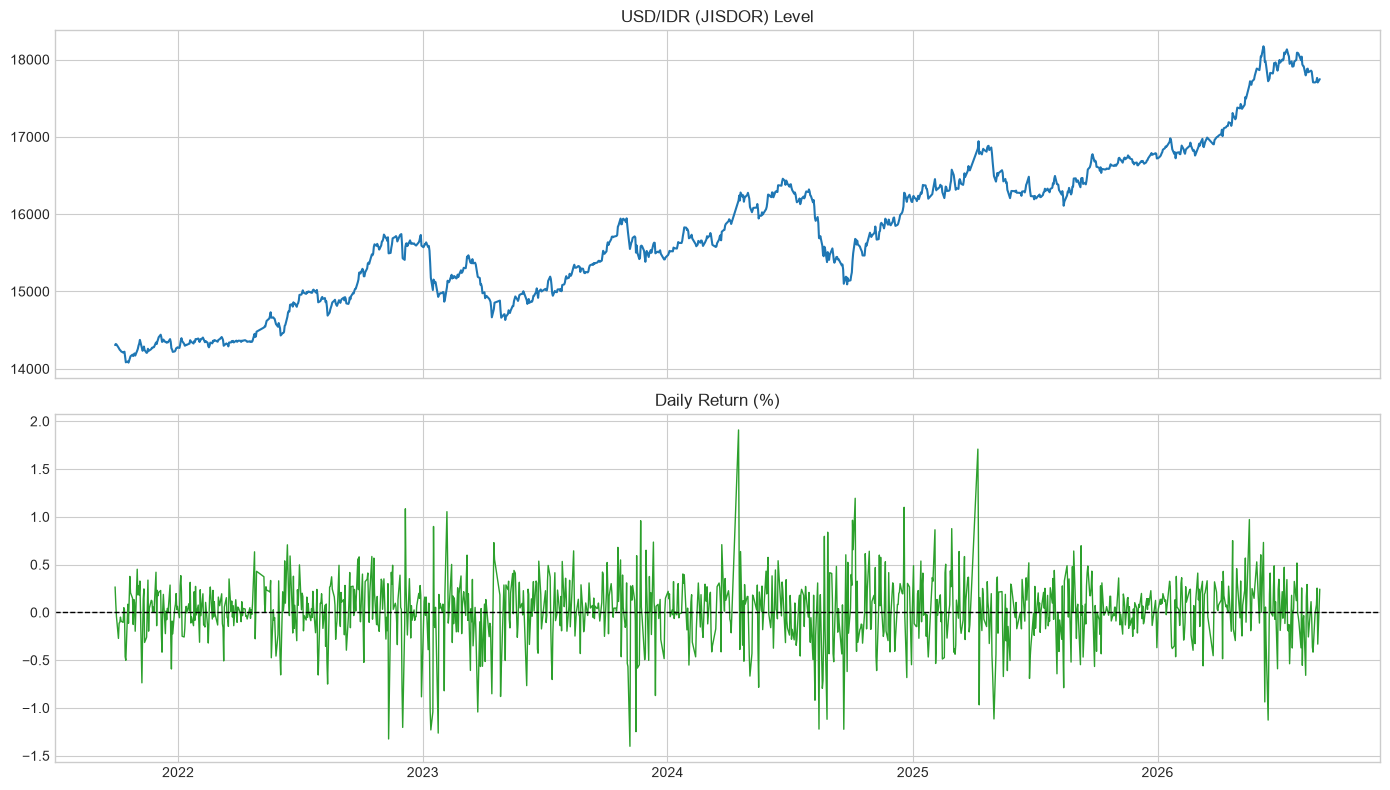

In [5]:
df_rates_clean = build_rate_features(df_rates)
print(f"Trading days with complete technical features: {len(df_rates_clean)}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
dates = pd.to_datetime(df_rates_clean["Date"])
ax1.plot(dates, df_rates_clean["USD_IDR"], color="#1f77b4")
ax1.set_title("USD/IDR (JISDOR) Level")
ax2.plot(dates, df_rates_clean["return_t"] * 100, color="#2ca02c", lw=1)
ax2.axhline(0, color="black", lw=1, linestyle="--")
ax2.set_title("Daily Return (%)")
plt.tight_layout()
plt.show()

## 4. News Sentiment Scoring (VADER + Loughran-McDonald)

In [6]:
df_news_scored = score_news_sentiment(df_news_clean)
merged = aggregate_and_merge(df_rates_clean, df_news_scored)

print(f"Merged dataset: {merged.shape}")
print(f"Trading days with news: {int(merged['has_news'].sum())} "
      f"({merged['has_news'].sum() / len(merged) * 100:.1f}%)")

Merged dataset: (1181, 43)
Trading days with news: 1180 (99.9%)


## 5. Chronological Train / Validation / Test Split

In [7]:
train_df, val_df, test_df = chronological_split(merged)

print(f"Train: {train_df['Date'].min()} to {train_df['Date'].max()} | N={len(train_df)} | News days={int(train_df['has_news'].sum())}")
print(f"Val:   {val_df['Date'].min()} to {val_df['Date'].max()} | N={len(val_df)} | News days={int(val_df['has_news'].sum())}")
print(f"Test:  {test_df['Date'].min()} to {test_df['Date'].max()} | N={len(test_df)} | News days={int(test_df['has_news'].sum())}")

train_df, val_df, test_df = add_tfidf_topics(train_df, val_df, test_df)

Train: 2021-09-29 to 2025-02-25 | N=826 | News days=826
Val:   2025-02-26 to 2025-11-25 | N=177 | News days=177
Test:  2025-11-26 to 2026-08-31 | N=178 | News days=177


## 6. Baseline Model (Technical Features Only)

Historical exchange-rate data only — no news features. This is the benchmark
that any NLP-informed model must beat to justify the added complexity.

In [8]:
baseline_results, baseline_models, baseline_scaler = train_baseline_models(train_df, test_df)
baseline_results.round(4)

,Model,Directional Accuracy,Precision,Recall,F1 (Macro),ROC-AUC
0,Naive: Majority Class,0.5787,0.5787,1.0000,0.3665,0.5000
1,Naive: Momentum (t-1),0.5449,0.6058,0.6117,0.5325,0.5000
2,TS Baseline: Logistic Regression,0.5506,0.5742,0.8641,0.4368,0.5500
3,TS Baseline: XGBoost,0.5730,0.5871,0.8835,0.4650,0.5373
4,TS Baseline: Random Forest,0.5955,0.5975,0.9223,0.4796,0.5043


## 7. Combined Model (Technical + NLP Features)

In [9]:
combined_results, combined_models, combined_scaler = train_combined_models(train_df, test_df)
combined_results.round(4)

,Model,Directional Accuracy,Precision,Recall,F1 (Macro),ROC-AUC
0,Combined: Logistic Regression,0.5169,0.5659,0.7087,0.4679,0.4683
1,Combined: Random Forest,0.5787,0.5854,0.9320,0.4382,0.5271
2,Combined: XGBoost,0.5674,0.5844,0.8738,0.4613,0.5200
3,Combined: Soft-Voting Ensemble,0.5674,0.5878,0.8447,0.4799,0.4961


In [10]:
benchmark = pd.concat([baseline_results, combined_results], ignore_index=True)
print("=== FULL TEST SET: BASELINE vs COMBINED ===")
benchmark.round(4)

=== FULL TEST SET: BASELINE vs COMBINED ===


,Model,Directional Accuracy,Precision,Recall,F1 (Macro),ROC-AUC
0,Naive: Majority Class,0.5787,0.5787,1.0000,0.3665,0.5000
1,Naive: Momentum (t-1),0.5449,0.6058,0.6117,0.5325,0.5000
2,TS Baseline: Logistic Regression,0.5506,0.5742,0.8641,0.4368,0.5500
3,TS Baseline: XGBoost,0.5730,0.5871,0.8835,0.4650,0.5373
4,TS Baseline: Random Forest,0.5955,0.5975,0.9223,0.4796,0.5043
5,Combined: Logistic Regression,0.5169,0.5659,0.7087,0.4679,0.4683
6,Combined: Random Forest,0.5787,0.5854,0.9320,0.4382,0.5271
7,Combined: XGBoost,0.5674,0.5844,0.8738,0.4613,0.5200
8,Combined: Soft-Voting Ensemble,0.5674,0.5878,0.8447,0.4799,0.4961


## 8. Evaluation on News-Active Days Only

If NLP features carry real signal, it should show up most clearly on the
subset of days where news actually occurred.

In [11]:
active_results, active_df = evaluate_on_active_days(
    test_df, baseline_models, baseline_scaler, combined_models, combined_scaler
)
print(f"News-active test days: {len(active_df)}")
active_results.round(4) if len(active_results) else "Not enough active-day data for a clean evaluation."

News-active test days: 177


,Model,Directional Accuracy,Precision,Recall,F1 (Macro),ROC-AUC
0,TS Baseline: Random Forest,0.5932,0.5949,0.9216,0.4786,0.5076
1,TS Baseline: XGBoost,0.5706,0.5844,0.8824,0.4638,0.5412
2,Combined: Random Forest,0.5763,0.5828,0.9314,0.4371,0.5226
3,Combined: XGBoost,0.5650,0.5817,0.8725,0.4601,0.5154
4,Combined: Soft-Voting Ensemble,0.5650,0.5850,0.8431,0.4787,0.4911


## 9. Regression Formulation (Next-Day Return)

In [12]:
regression_results = train_regression(train_df, test_df)
regression_results.round(6)

,Model,RMSE,MAE,Directional Accuracy
0,Ridge,0.003062,0.002317,0.505618
1,XGBoost,0.002962,0.002267,0.494382


## 10. Ablation Study

Isolates whether title sentiment, body sentiment, or their combination
contributes most, versus the full multimodal feature set.

In [13]:
ablation_results = ablation_study(train_df, test_df)
ablation_results.round(4)

,Model,Num Features,Directional Accuracy,F1 (Macro),ROC-AUC
0,1. Technical Only,12,0.5730,0.4650,0.5373
1,2. Technical + Title Sentiment,22,0.5169,0.4343,0.4993
2,3. Technical + Body Sentiment,17,0.5618,0.4438,0.5245
3,4. Technical + Title + Body,27,0.5730,0.4650,0.5262
4,5. Full Multimodal,34,0.5674,0.4613,0.5200


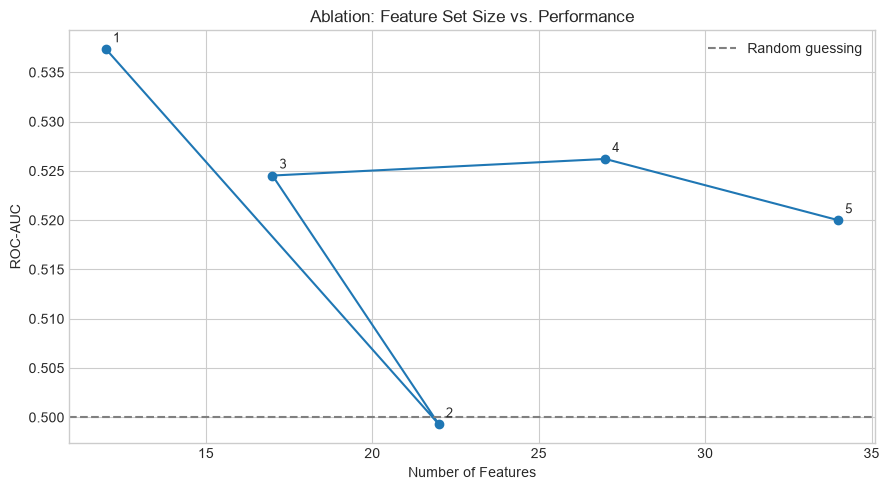

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(ablation_results["Num Features"], ablation_results["ROC-AUC"], marker="o")
for _, row in ablation_results.iterrows():
    plt.annotate(row["Model"].split(". ")[0], (row["Num Features"], row["ROC-AUC"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
plt.xlabel("Number of Features")
plt.ylabel("ROC-AUC")
plt.title("Ablation: Feature Set Size vs. Performance")
plt.axhline(0.5, color="gray", linestyle="--", label="Random guessing")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Summary

This notebook was run against a **partial, still-growing** CNBC corpus (the
scraper collects ~24,000 candidate articles from CNBC's sitemaps; this run
used whatever had been collected at execution time — see the article count in
Section 1). Headline comparison:

- The **technical-only baseline** (historical exchange-rate features alone)
  is the benchmark to beat.
- The **combined model** adds VADER and Loughran-McDonald sentiment (title and
  body), a TF-IDF/SVD topic signal, and news-activity counts.
- Results should be read together with the **news-active-days** evaluation
  (Section 8) and the **ablation study** (Section 10), which isolate whether
  any specific NLP feature group is driving (or hurting) performance, rather
  than relying on the aggregate benchmark table alone.

This structure — baseline vs. combined, evaluated on both the full test set
and the news-active subset, plus an ablation over feature groups — is the
minimum needed to make a defensible claim either way about whether the added
NLP features improve on the historical-price-only baseline.